# Activity 3 — Prescriptive Analytics (Genetic Algorithm)
**Course:** Data Analytics (10204210) | **Dataset:** Emergency Response

Objective: Use a Genetic Algorithm (GA) to find the optimal weight coefficients
that minimize prediction error for the Response Time formula:

```
RT = w1*Distance + w2*Injuries + w3*Hospital_Capacity + w4*Fuel_Level + b
```

**Fitness Function:** Negative RMSE (GA maximises fitness = minimises prediction error)

**Constraints:**
- w1 (Distance): [0.2, 0.8]
- w2 (Injuries): [0.1, 0.5]
- w3 (Hospital_Capacity): [0.0, 0.03]
- w4 (Fuel_Level): [0.0, 0.04]
- b  (Baseline): [5.0, 10.0]

In [1]:
!pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.3 MB/s eta 0:00:00


In [2]:
import pygad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# Load data
df = pd.read_csv('df_clean.csv', parse_dates=['Timestamp'])

# Take 2018-2019 subset
df = df[df['Year'].isin([2018, 2019])].copy()
df.reset_index(drop=True, inplace=True)
print('Subset shape:', df.shape)

Subset shape: (105120, 22)


In [4]:
# Extract the 4 GA features and the target
X_ga = df[['Distance_to_Incident', 'Number_of_Injuries',
           'Hospital_Capacity', 'Fuel_Level']].to_numpy()
y_ga = df['Response_Time'].to_numpy()

print('X_ga shape:', X_ga.shape)
print('y_ga shape:', y_ga.shape)
print('\nFeature statistics:')
print(pd.DataFrame(X_ga, columns=['Distance','Injuries','HospCap','Fuel']).describe().round(2))

X_ga shape: (105120, 4)
y_ga shape: (105120,)

Feature statistics:
        Distance   Injuries    HospCap       Fuel
count  105120.00  105120.00  105120.00  105120.00
mean       25.46       1.52      54.51      69.91
std        14.14       0.73      26.02      14.68
min         1.00       1.00      10.00      10.00
25%        13.20       1.00      32.00      59.93
50%        25.44       1.00      55.00      70.09
75%        37.69       2.00      77.00      80.14
max        50.00       4.00      99.00     100.00


## Define the Fitness Function

In [ ]:
# Fitness function — returns negative RMSE
# pygad maximises the fitness value
# So maximising -RMSE = minimising RMSE = better prediction accuracy
def fitness_func(ga_instance, solution, solution_idx):
    w1, w2, w3, w4, b = solution

    # Apply the Response Time formula
    y_pred = (w1 * X_ga[:, 0] +   # w1 x Distance
              w2 * X_ga[:, 1] +   # w2 x Injuries
              w3 * X_ga[:, 2] +   # w3 x Hospital_Capacity
              w4 * X_ga[:, 3] +   # w4 x Fuel_Level
              b)                   # baseline

    # Compute RMSE
    rmse = np.sqrt(np.mean((y_ga - y_pred) ** 2)) #

    # Return negative RMSE (GA maximises this = minimises RMSE)
    return -rmse

## Configure and Run the Genetic Algorithm

In [6]:
# Gene space: constraint bounds for each decision variable
gene_space = [
    {'low': 0.2,  'high': 0.8},    # w1 — Distance coefficient
    {'low': 0.1,  'high': 0.5},    # w2 — Injuries coefficient
    {'low': 0.0,  'high': 0.03},   # w3 — Hospital_Capacity coefficient
    {'low': 0.0,  'high': 0.04},   # w4 — Fuel_Level coefficient
    {'low': 5.0,  'high': 10.0},   # b  — Baseline intercept
]

# Create the GA instance
ga_instance = pygad.GA(
    num_generations      = 300,        # number of evolution cycles
    num_parents_mating   = 10,         # parents selected per generation
    fitness_func         = fitness_func,
    sol_per_pop          = 50,         # population size
    num_genes            = 5,          # [w1, w2, w3, w4, b]
    gene_space           = gene_space, # constraint bounds
    parent_selection_type= 'tournament',
    crossover_type       = 'uniform',
    mutation_type        = 'random',
    mutation_percent_genes= 20,        # 20% of genes mutate per chromosome
    keep_elitism         = 5,          # keep top 5 chromosomes unchanged
    random_seed          = 42,
)

print('GA configured. Running...')
ga_instance.run()
print('GA complete.')

GA configured. Running...
GA complete.


## Results — Optimal Solution

In [7]:
# Get the best solution
solution, solution_fitness, solution_idx = ga_instance.best_solution()
w1, w2, w3, w4, b = solution

print('=' * 55)
print('OPTIMAL DECISION VARIABLE VALUES')
print('=' * 55)
print(f'  w1 (Distance coefficient)    = {w1:.6f}  [0.2, 0.8]')
print(f'  w2 (Injuries coefficient)    = {w2:.6f}  [0.1, 0.5]')
print(f'  w3 (Hospital_Cap coefficient)= {w3:.6f}  [0.0, 0.03]')
print(f'  w4 (Fuel_Level coefficient)  = {w4:.6f}  [0.0, 0.04]')
print(f'  b  (Baseline intercept)      = {b:.6f}  [5.0, 10.0]')
print(f'\n  Best Fitness (−RMSE)         = {solution_fitness:.6f}')
print(f'  Best RMSE                    = {-solution_fitness:.6f} min')

OPTIMAL DECISION VARIABLE VALUES
  w1 (Distance coefficient)    = 0.201090  [0.2, 0.8]
  w2 (Injuries coefficient)    = 0.100428  [0.1, 0.5]
  w3 (Hospital_Cap coefficient)= 0.001734  [0.0, 0.03]
  w4 (Fuel_Level coefficient)  = 0.004096  [0.0, 0.04]
  b  (Baseline intercept)      = 9.400182  [5.0, 10.0]

  Best Fitness (−RMSE)         = -5.656254
  Best RMSE                    = 5.656254 min


In [8]:
# Print the final formula
print('FINAL RESPONSE TIME FORMULA:')
print(f'RT = {w1:.4f} x Distance')
print(f'   + {w2:.4f} x Number_of_Injuries')
print(f'   + {w3:.4f} x Hospital_Capacity')
print(f'   + {w4:.4f} x Fuel_Level')
print(f'   + {b:.4f}')

FINAL RESPONSE TIME FORMULA:
RT = 0.2011 x Distance
   + 0.1004 x Number_of_Injuries
   + 0.0017 x Hospital_Capacity
   + 0.0041 x Fuel_Level
   + 9.4002


##the optimiser found that the least-wrong thing to do, under these constraints, is to barely use the features and instead predict a near-constant value close to the data's average (~15 min). That's the no-signal story again — the features don't help, so the model leans on the intercept. The lower-bound constraints are the only reason the weights aren't pushed all the way to zero.



## Performance Evaluation

In [9]:
# Compute predicted Response_Time for all incidents
y_pred_ga = (w1 * X_ga[:, 0] +
             w2 * X_ga[:, 1] +
             w3 * X_ga[:, 2] +
             w4 * X_ga[:, 3] +
             b)

# Metrics
ga_mae  = mean_absolute_error(y_ga, y_pred_ga)
ga_mse  = mean_squared_error(y_ga, y_pred_ga)
ga_rmse = np.sqrt(ga_mse)
ga_r2   = r2_score(y_ga, y_pred_ga)

avg_actual    = y_ga.mean()
avg_predicted = y_pred_ga.mean()

print('PERFORMANCE EVALUATION (all incidents):')
print(f'  Average Actual Response Time    : {avg_actual:.4f} min')
print(f'  Average Predicted Response Time : {avg_predicted:.4f} min')
print(f'  Difference (Predicted - Actual) : {avg_predicted - avg_actual:+.4f} min')
print(f'  MAE  = {ga_mae:.4f} min')
print(f'  MSE  = {ga_mse:.4f}')
print(f'  RMSE = {ga_rmse:.4f} min')
print(f'  R²   = {ga_r2:.4f}')

PERFORMANCE EVALUATION (all incidents):
  Average Actual Response Time    : 15.0701 min
  Average Predicted Response Time : 15.0541 min
  Difference (Predicted - Actual) : -0.0160 min
  MAE  = 4.5588 min
  MSE  = 31.9932
  RMSE = 5.6563 min
  R²   = -0.3401


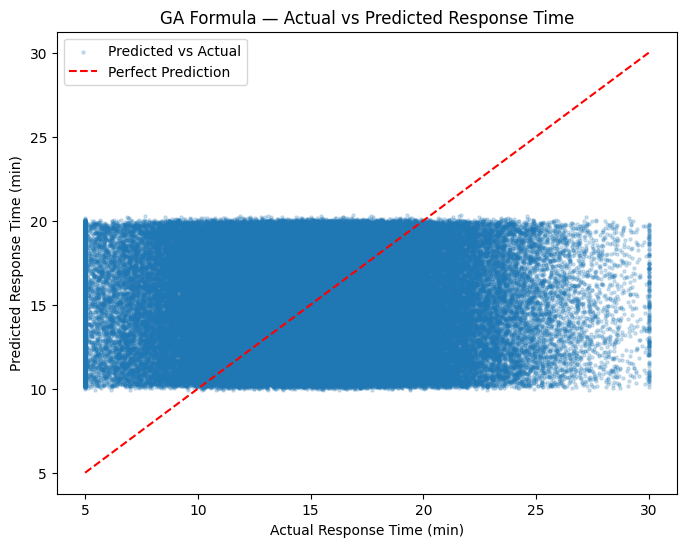

In [10]:
# Plot Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_ga, y_pred_ga, alpha=0.2, s=5, label='Predicted vs Actual')
plt.plot([y_ga.min(), y_ga.max()], [y_ga.min(), y_ga.max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.title('GA Formula — Actual vs Predicted Response Time')
plt.xlabel('Actual Response Time (min)')
plt.ylabel('Predicted Response Time (min)')
plt.legend()
plt.show()

## Convergence Analysis

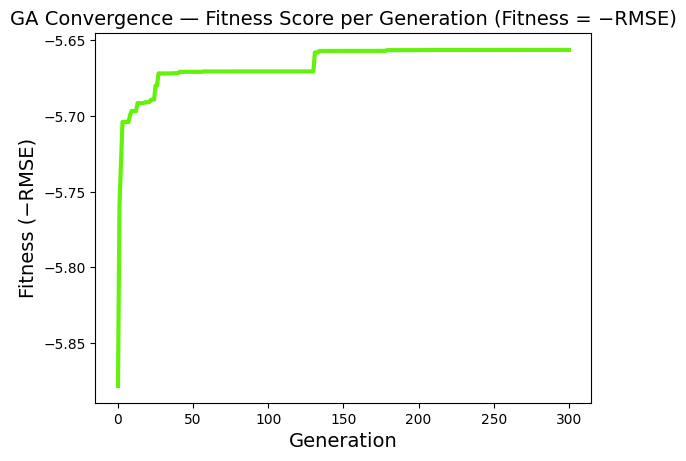

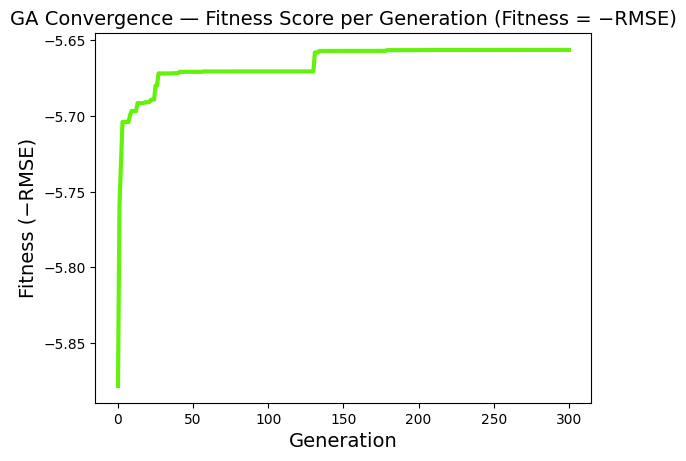

In [11]:
# Plot fitness convergence — built-in pygad method
ga_instance.plot_fitness(
    title='GA Convergence — Fitness Score per Generation (Fitness = −RMSE)',
    xlabel='Generation',
    ylabel='Fitness (−RMSE)'
)

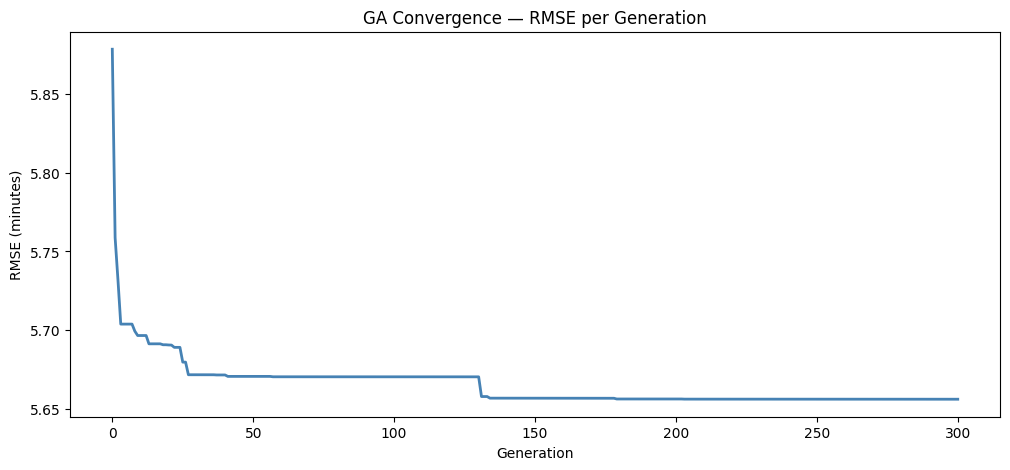

Initial RMSE (gen 1)     : 5.8782 min
Final RMSE (gen 301): 5.6563 min
Improvement              : 0.221989 min


In [12]:
# Average predicted Response Time per generation
# Retrieve best solution fitness at each generation
best_fitness_values = ga_instance.best_solutions_fitness

# Convert fitness to RMSE values
rmse_per_gen = [-f for f in best_fitness_values]

plt.figure(figsize=(12, 5))
plt.plot(rmse_per_gen, color='steelblue', linewidth=2)
plt.title('GA Convergence — RMSE per Generation')
plt.xlabel('Generation')
plt.ylabel('RMSE (minutes)')
plt.show()

print(f'Initial RMSE (gen 1)     : {rmse_per_gen[0]:.4f} min')
print(f'Final RMSE (gen {len(rmse_per_gen)}): {rmse_per_gen[-1]:.4f} min')
print(f'Improvement              : {rmse_per_gen[0] - rmse_per_gen[-1]:.6f} min')

In [13]:
# Summary
print('ACTIVITY 3 COMPLETE')
print()
print(f'Optimal Formula:')
print(f'RT = {w1:.4f}*Distance + {w2:.4f}*Injuries + {w3:.4f}*HospCap + {w4:.4f}*Fuel + {b:.4f}')
print()
print(f'Avg Actual RT    : {avg_actual:.4f} min')
print(f'Avg Predicted RT : {avg_predicted:.4f} min')
print(f'Difference       : {avg_predicted - avg_actual:+.4f} min')
print(f'RMSE             : {ga_rmse:.4f} min')

ACTIVITY 3 COMPLETE

Optimal Formula:
RT = 0.2011*Distance + 0.1004*Injuries + 0.0017*HospCap + 0.0041*Fuel + 9.4002

Avg Actual RT    : 15.0701 min
Avg Predicted RT : 15.0541 min
Difference       : -0.0160 min
RMSE             : 5.6563 min
